In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import keras_tuner as kt
import tensorboard
from tensorflow import keras
from tensorflow.keras import utils, layers
from tensorflow.keras.callbacks import ModelCheckpoint
from keras_tuner import HyperParameters
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import math

print(tf.__version__)
print("Liczba dostępnych GPU:", len(tf.config.list_physical_devices('GPU')))
print("Dostępne urządzenia:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1787762374.760650    2181 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787762374.905431    2181 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787762376.970502    2181 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.21.0
Liczba dostępnych GPU: 1
Dostępne urządzenia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1787762379.414251    2181 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [3]:
import sys
import os

print("Wersja platformy:", sys.platform)
print("Ścieżka do Pythona:", sys.executable)

Wersja platformy: linux
Ścieżka do Pythona: /home/nagorny/miniconda3/envs/tf_gpu_wsl/bin/python3.11


## Downloading Dataset

In [4]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_test.shape, y_test.shape)

(10000, 32, 32, 3) (10000, 1)


## Analysing the dataset

In [5]:
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def countClass(labels: np.array):
    unique, counts = np.unique(labels, return_counts=True)
    for class_id, count in zip(unique, counts):
        print(f"{class_id}: {classes[class_id]} -> {count}")

countClass(y_train)


0: airplane -> 5000
1: automobile -> 5000
2: bird -> 5000
3: cat -> 5000
4: deer -> 5000
5: dog -> 5000
6: frog -> 5000
7: horse -> 5000
8: ship -> 5000
9: truck -> 5000


In [7]:
print(y_test[0]) #CategoricalCrossentropy or SparseCategoricalCrossentropy

[3]


## Preparing validation set

In [22]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(x_train))
split = int(0.85*len(x_train))
idx_train = idx[:split]
idx_val = idx[split:]

x_val = x_train[idx_val]
y_val = y_train[idx_val]
x_train = x_train[idx_train]
y_train = y_train[idx_train]

print(f"Training set size: X={x_train.shape} Y={y_train.shape}")
print(f"Validation set size: X={x_val.shape} Y={y_val.shape}")
print(f"Test set size: X={x_test.shape} Y={y_test.shape}")

#Verifying if there is no class disproportion
countClass(y_train)
countClass(y_val)

Training set size: X=(42500, 32, 32, 3) Y=(42500, 1)
Validation set size: X=(7500, 32, 32, 3) Y=(7500, 1)
Test set size: X=(10000, 32, 32, 3) Y=(10000, 1)
0: airplane -> 4288
1: automobile -> 4259
2: bird -> 4246
3: cat -> 4221
4: deer -> 4285
5: dog -> 4230
6: frog -> 4178
7: horse -> 4263
8: ship -> 4274
9: truck -> 4256
0: airplane -> 712
1: automobile -> 741
2: bird -> 754
3: cat -> 779
4: deer -> 715
5: dog -> 770
6: frog -> 822
7: horse -> 737
8: ship -> 726
9: truck -> 744


## Data Normalization

In [23]:
x_train = x_train.astype('float32')/255.0
x_val = x_val.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

# ***DNN Models with MLP architecture***

**Model with no dropout**

In [24]:
def build_model(hp: kt.HyperParameters, Dropout=False, activation='relu'):
    n_hidden = hp.Int('n_hidden', min_value=1, max_value=8, default=2)
    n_neurons = hp.Int('n_neurons', min_value=64, max_value=512, step=64, default=256)
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=3*1e-2, sampling='log')
    if Dropout:
        dropout = hp.Float('dropout', min_value=0.3, max_value=0.6, step=0.1)
    optimizer = hp.Choice('optimizer', values=["sgd", "adam", "adamW"])
    if optimizer=="sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer=="adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer=tf.keras.optimizers.AdamW(learning_rate=learning_rate)

    model=tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, kernel_initializer='he_normal'))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Activation(activation))
        if Dropout:
                  model.add(tf.keras.layers.Dropout(dropout))
    model.add(tf.keras.layers.Dense(10, activation='softmax'))
    
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy']) 
    return model

In [8]:
rst = kt.RandomSearch(build_model, objective='val_accuracy', max_trials=50, seed=42, overwrite=False, directory='my_cifar10', project_name='my_rnd_serach')
rst.search(x_train, y_train, epochs=30, validation_data=(x_val, y_val))

Reloading Tuner from my_cifar10/my_rnd_serach/tuner0.json


W0000 00:00:1786123051.557781     555 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1786123051.718730     555 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [9]:
print("MLP model (no Dropout) with the best found parameters:")
top_params = rst.oracle.get_best_trials(num_trials=3)
top_params[0].summary()

MLP model (no Dropout) with the best found parameters:
Trial 38 summary
Hyperparameters:
n_hidden: 7
n_neurons: 320
learning_rate: 0.00406107655152487
optimizer: adam
Score: 0.5298666954040527


In [25]:
rst2 = kt.RandomSearch(
    hypermodel=lambda hp: build_model(hp, Dropout=True), 
    objective='val_accuracy', 
    max_trials=50, 
    seed=42, 
    overwrite=False, 
    directory='my_cifar10', 
    project_name='my_rnd_serach_with_Dropout')
rst2.search(x_train, y_train, epochs=65, validation_data=(x_val, y_val))

Reloading Tuner from my_cifar10/my_rnd_serach_with_Dropout/tuner0.json


In [26]:
print("MLP model (with Dropout) with the best found hyperparameters:")
top_params_withDrop = rst2.oracle.get_best_trials(num_trials=3)
bestTrial=top_params_withDrop[0]
bestTrial.summary()

MLP model (with Dropout) with the best found hyperparameters:
Trial 41 summary
Hyperparameters:
n_hidden: 4
n_neurons: 448
learning_rate: 0.0004693728843708382
dropout: 0.4
optimizer: adam
Score: 0.5651999711990356


## Training best model for Learning Curve

In [27]:
best_hp = rst2.get_best_hyperparameters(1)[0]

model = build_model(best_hp, Dropout=True)

checkpoint = ModelCheckpoint(
    'cifar10_best_dropout_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

#Uncomment to train model to get its learning history
#history = model.fit(
#    x_train,
#    y_train,
#    epochs=120,
#    validation_data=(x_val, y_val),
#    callbacks=[checkpoint]
#)

## Model evaluation

In [28]:
model = tf.keras.models.load_model('cifar10_best_dropout_model.keras')
loss, accuracy = model.evaluate(x=x_test, y=y_test)

print(f"Loss: {loss}, Accuracy: {accuracy}")

I0000 00:00:1786271473.098810     792 service.cc:153] XLA service 0x6549d967c7b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786271473.098843     792 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786271473.128631     792 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786271473.186779     792 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1786271473.208409     792 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786271473.638204    1373 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory 

107/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5406 - loss: 1.2844

I0000 00:00:1786271474.662628     792 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


290/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5447 - loss: 1.2709

I0000 00:00:1786271475.316187    1481 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 8 bytes spill stores, 8 bytes spill loads



313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5430 - loss: 1.2737
Loss: 1.2737457752227783, Accuracy: 0.5429999828338623


## Learning Curve

In [16]:
best_epoch = np.argmin(history.history['val_loss'])
best_loss = history.history['val_loss'][best_epoch]
best_val_acc = history.history['val_accuracy'][best_epoch]

epochs = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(12,4))

#Loss Function
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Function')
plt.xlabel('Epoka')
plt.legend()

plt.axvline(
    best_epoch + 1,
    linestyle='--',
    label=f'Best model (epoch {best_epoch + 1})',
    color='red',
)

plt.scatter(
    best_epoch + 1,
    best_loss,
    s=20,
    color='red',
)

#Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy')
plt.xlabel('Epoka')
plt.legend()

plt.axvline(
    best_epoch + 1,
    linestyle='--',
    label=f'Best model (epoch {best_epoch + 1})',
    color='red',
)

plt.scatter(
    best_epoch + 1,
    best_val_acc,
    s=20,
    color='red',
)

plt.show()

NameError: name 'history' is not defined

Conclusion: EarlyStopping may be more useful while training models for relatively big number of epochs as it prevents overfitting. Learning Diagrams show, that model is moderately overfitted, yet it didn't affect its effeciency as it stayed at the level of ~55%.

## MLP Model with Dropout and Leaky ReLU

In [21]:
rst3=kt.RandomSearch(
    hypermodel=lambda hp: build_model(hp, Dropout=True, activation='leaky_relu'), 
    objective='val_accuracy',
    max_trials=50, 
    seed=42, 
    overwrite=False, 
    directory='my_cifar10', 
    project_name='my_rnd_serach_with_Dropout_LeakyReLU'
)
rst3.search(x_train, y_train, epochs=65, validation_data=(x_val, y_val))

Reloading Tuner from my_cifar10/my_rnd_serach_with_Dropout_LeakyReLU/tuner0.json


In [22]:
best_hp2 = rst3.get_best_hyperparameters(1)[0]

model2 = build_model(best_hp2, Dropout=True, activation='leaky_relu')

checkpoint2 = ModelCheckpoint(
    'cifar10_best_dropout_model_Leaky.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

history2 = model2.fit(
    x_train,
    y_train,
    epochs=40,
    validation_data=(x_val, y_val),
    callbacks=[checkpoint2]
)

Epoch 1/40


I0000 00:00:1785866059.791495     817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_48179__.67
I0000 00:00:1785866060.136863     817 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1785866060.515606    3905 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_46', 96 bytes spill stores, 96 bytes spill loads



1325/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2475 - loss: 2.1552

I0000 00:00:1785866066.926144     818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_48179__.67


1329/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2475 - loss: 2.1553

I0000 00:00:1785866072.139943    4355 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 8 bytes spill stores, 8 bytes spill loads



1329/1329 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.2475 - loss: 2.1553 - val_accuracy: 0.3516 - val_loss: 1.7660
Epoch 2/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3227 - loss: 1.8772 - val_accuracy: 0.4033 - val_loss: 1.6718
Epoch 3/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3676 - loss: 1.7591 - val_accuracy: 0.4077 - val_loss: 1.6631
Epoch 4/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 1s 761us/step - accuracy: 0.3922 - loss: 1.6942 - val_accuracy: 0.3949 - val_loss: 1.6932
Epoch 5/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4145 - loss: 1.6406 - val_accuracy: 0.4381 - val_loss: 1.5755
Epoch 6/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4313 - loss: 1.5964 - val_accuracy: 0.4541 - val_loss: 1.5172
Epoch 7/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4445 - loss: 1.5641 - val_accuracy: 0.4707 - val_loss: 1.4760
Epoch 8/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4574 - loss: 1.5216 - val_accu

In [34]:
model2 = tf.keras.models.load_model('cifar10_best_dropout_model_Leaky.keras')
loss, accuracy = model2.evaluate(x=x_test, y=y_test)

print(f"Loss: {loss}, Accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5383 - loss: 1.2749
Loss: 1.274898886680603, Accuracy: 0.5382999777793884


## MLP Model with Dropout and Silu as activation function

In [26]:
rst4=kt.RandomSearch(
    hypermodel=lambda hp: build_model(hp, Dropout=True, activation='silu'), 
    objective='val_accuracy',
    max_trials=50, 
    seed=42, 
    overwrite=False, 
    directory='my_cifar10', 
    project_name='my_rnd_serach_with_Dropout_Swift'
)
rst4.search(x_train, y_train, epochs=40, validation_data=(x_val, y_val))

Reloading Tuner from my_cifar10/my_rnd_serach_with_Dropout_Swift/tuner0.json


In [29]:
best_hp4 = rst4.get_best_hyperparameters()[0]
model4 = build_model(best_hp4, Dropout=True, activation='silu')

checkpoint4 = ModelCheckpoint(
    'cifar10_best_dropout_model_SiLU.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

history4 = model4.fit(
    x_train,
    y_train,
    epochs=40,
    validation_data=(x_val, y_val),
    callbacks=[checkpoint4]
)

Epoch 1/40


I0000 00:00:1785866604.525352     820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_582688__.74


1309/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2565 - loss: 2.1001

I0000 00:00:1785866610.305697     816 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_582688__.74


1329/1329 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.2572 - loss: 2.0974 - val_accuracy: 0.3533 - val_loss: 1.8001
Epoch 2/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3463 - loss: 1.8149 - val_accuracy: 0.3825 - val_loss: 1.7334
Epoch 3/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 1s 925us/step - accuracy: 0.3886 - loss: 1.7035 - val_accuracy: 0.4321 - val_loss: 1.5702
Epoch 4/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4128 - loss: 1.6416 - val_accuracy: 0.4328 - val_loss: 1.5555
Epoch 5/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4379 - loss: 1.5793 - val_accuracy: 0.4588 - val_loss: 1.5194
Epoch 6/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4548 - loss: 1.5369 - val_accuracy: 0.4513 - val_loss: 1.5210
Epoch 7/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4656 - loss: 1.5040 - val_accuracy: 0.4592 - val_loss: 1.5119
Epoch 8/40
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4761 - loss: 1.4725 - val_accu

In [35]:
model4=tf.keras.models.load_model('cifar10_best_dropout_model_SiLU.keras')
loss, accuracy = model4.evaluate(x_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5423 - loss: 1.2746
Loss: 1.2746012210845947, Accuracy: 0.5422999858856201


## Confusion Matrixes Analysis and Comparison

In [ ]:
def printConfusionMatrix(model, name: str= None):
    y_pred = np.argmax(model.predict(x_test), axis=1)
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Prediction')
    plt.ylabel('True label')
    plt.title('Confusion Matrix '+name)
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


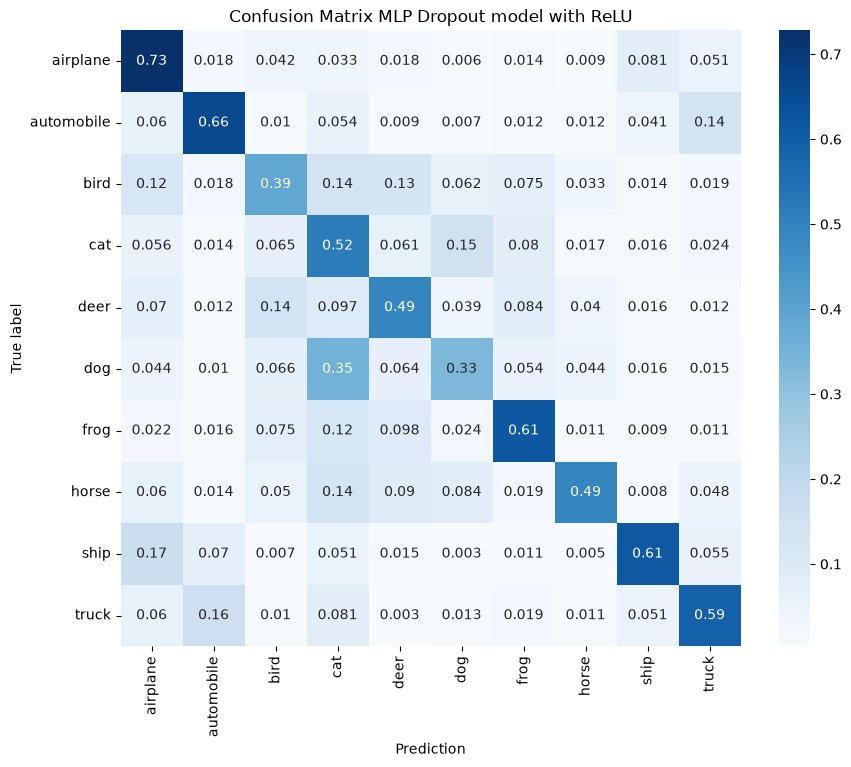

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


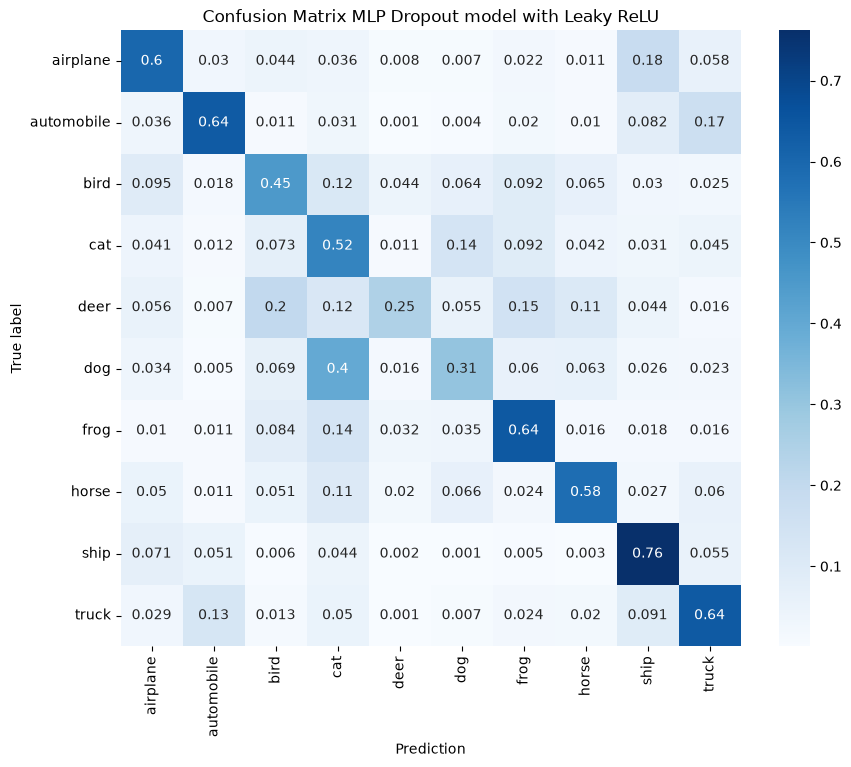

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


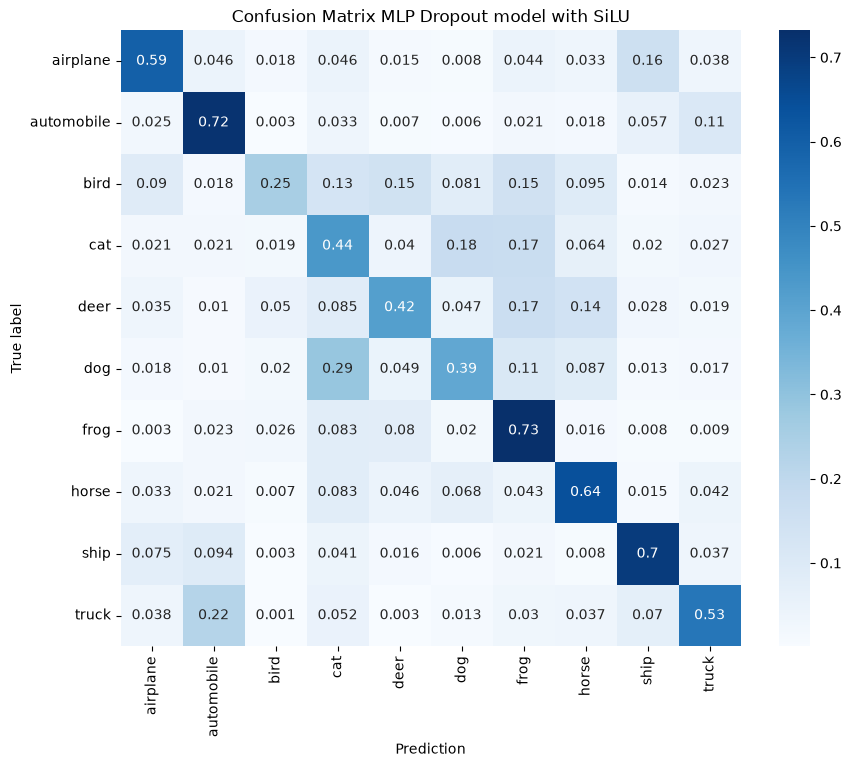

In [36]:
printConfusionMatrix(model, "MLP Dropout model with ReLU")
printConfusionMatrix(model2, "MLP Dropout model with Leaky ReLU")
printConfusionMatrix(model4, "MLP Dropout model with SiLU")

Comparing all three models with different activation functions, the most useful is the one using ReLU, even though every one of them achieves accuracy around ~55%:
- SiLU model and Leaky ReLU model has at least one extremely confusing class where accuracy is not higher than 35%
- ReLU model confuses mostly two pairs of class: "Dog" <-> "Cat"; "Deer" - "Bird". LeakyReLU has troubles identifying deer at all among all available animal classes, also is more biased towards cat class. SiLU has troubles identifying birds and is often cofusing cat with dog, yet is not biased.
- All models have much less troubles with samples from Transport category.

## Monte Carlo DropOut Regularization for the best (ReLU) MLP model

Model contains Batch Normalization Layers, which allows model to update its moving statistics when parameter training=True is provided.
To perfom MC Regularization correctly, BatchNormalization's updates have to be disabled first.

In [40]:
def mc_predict(model, x, n_samples=100):
    predictions = []

    # BatchNormalization pozostaje w trybie inference
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    for _ in range(n_samples):
        outputs = x

        for layer in model.layers:
            if isinstance(layer, tf.keras.layers.Dropout):
                outputs = layer(outputs, training=True)
            else:
                outputs = layer(outputs, training=False)

        predictions.append(outputs.numpy())

    return np.stack(predictions)
    


In [63]:
y_MC_all = mc_predict(model, x_test, n_samples=100)

y_MC = y_MC_all.mean(axis=0)
y_predMC = y_MC.argmax(axis=1)

accuracyMC = (y_predMC == y_test.squeeze()).mean()

print(f"MC Dropout accuracy: {accuracyMC:.4f}")

MC Dropout accuracy: 0.5603


# Influence of batch size on models' efficiency

In [14]:
def build_model_BatchSizeTest(batch_size: int):
    best_hp = rst2.get_best_hyperparameters(1)[0]
    checkpoint_B=ModelCheckpoint(f'b{batch_size}_best_weights.weights.h5',
                                   monitor='val_loss', 
                                   save_weights_only=True, 
                                   save_best_only=True,
                                   mode='min')
    
    model_B = build_model(best_hp, Dropout=True)
        
    history_B = model_B.fit(
        x_train,
        y_train,
        batch_size=batch_size,
        epochs=40,
        validation_data=[x_val, y_val],
        callbacks=[checkpoint_B],
    )

    model_B.load_weights(f'b{batch_size}_best_weights.weights.h5')
    return model_B, history_B

model_b16, history_b16 = build_model_BatchSizeTest(16)
model_b32, history_b32 = build_model_BatchSizeTest(32)
model_b64, history_b64 = build_model_BatchSizeTest(64)
model_b128, history_b128 = build_model_BatchSizeTest(128)
model_b256, history_b256 = build_model_BatchSizeTest(256)
model_b512, history_b512 = build_model_BatchSizeTest(512)

NameError: name 'rst2' is not defined

### Batch_size=16

In [38]:
loss, acc = model_b16.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5587 - loss: 1.2466


### Batch_size = 32

In [39]:
loss, acc = model_b32.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5453 - loss: 1.2743


### Batch_size = 64

In [40]:
loss, acc = model_b64.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5412 - loss: 1.2937


### Batch_size = 128

In [41]:
loss, acc = model_b128.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5362 - loss: 1.3176


### Batch_size = 256

In [42]:
loss, acc = model_b256.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5145 - loss: 1.3460


### Batch_size = 512

In [43]:
loss, acc = model_b512.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5116 - loss: 1.3726


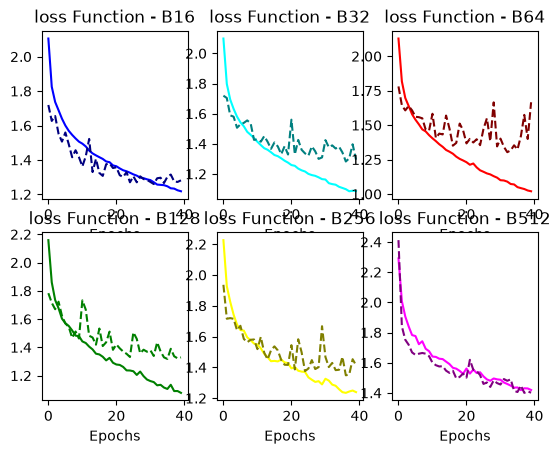

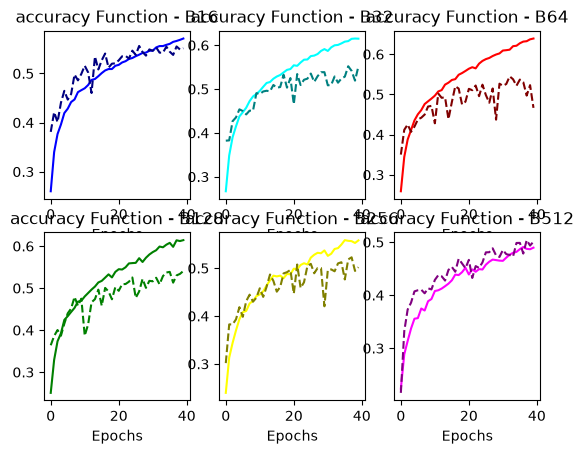

In [50]:
def raport(stat: str):
    plt.subplot(2,3,1)
    plt.title(f"{stat} Function - B16")
    plt.xlabel("Epochs")
    plt.plot(history_b16.history[stat], label=f'B16_Train_{stat}', color='Blue')
    plt.plot(history_b16.history[f'val_{stat}'], label=f'B16_val_{stat}', color=(0.,0.,0.5), linestyle='--')
    
    plt.subplot(2,3,2)
    
    plt.title(f"{stat} Function - B32")
    plt.xlabel("Epochs")
    plt.plot(history_b32.history[f'{stat}'], label=f'B32_Train_{stat}', color=(0.,1.,1.))
    plt.plot(history_b32.history[f'val_{stat}'], label=f'B32_val_{stat}', color=(0.,0.5,0.5), linestyle='--')
    
    plt.subplot(2,3,3)
    plt.title(f"{stat} Function - B64")
    plt.xlabel("Epochs")
    plt.plot(history_b64.history[f'{stat}'], label=f'B64_Train_{stat}', color='Red')
    plt.plot(history_b64.history[f'val_{stat}'], label=f'B64_val_{stat}', color=(0.5,0.,0.0), linestyle='--')
    
    plt.subplot(2,3,4)
    
    plt.title(f"{stat} Function - B128")
    plt.xlabel("Epochs")
    plt.plot(history_b128.history[f'{stat}'], label=f'B128_Train_{stat}', color='Green')
    plt.plot(history_b128.history[f'val_{stat}'], label=f'B128_val_{stat}', color=(0.,0.5,0.), linestyle='--')
    
    plt.subplot(2,3,5)
    
    plt.title(f"{stat} Function - B256")
    plt.xlabel("Epochs")
    plt.plot(history_b256.history[f'{stat}'], label=f'B256_Train_{stat}', color=(1.,1.,0.))
    plt.plot(history_b256.history[f'val_{stat}'], label=f'B256_val_{stat}', color=(0.5,0.5,0.), linestyle='--')
    
    plt.subplot(2,3,6)
    
    plt.title(f"{stat} Function - B512")
    plt.xlabel("Epochs")
    plt.plot(history_b512.history[f'{stat}'], label=f'B512_Train_{stat}', color=(1., 0., 1.))
    plt.plot(history_b512.history[f'val_{stat}'], label=f'B512_val_{stat}', color=(0.5,0.,0.5), linestyle='--')
    
    plt.show()

raport("loss")
raport('accuracy')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


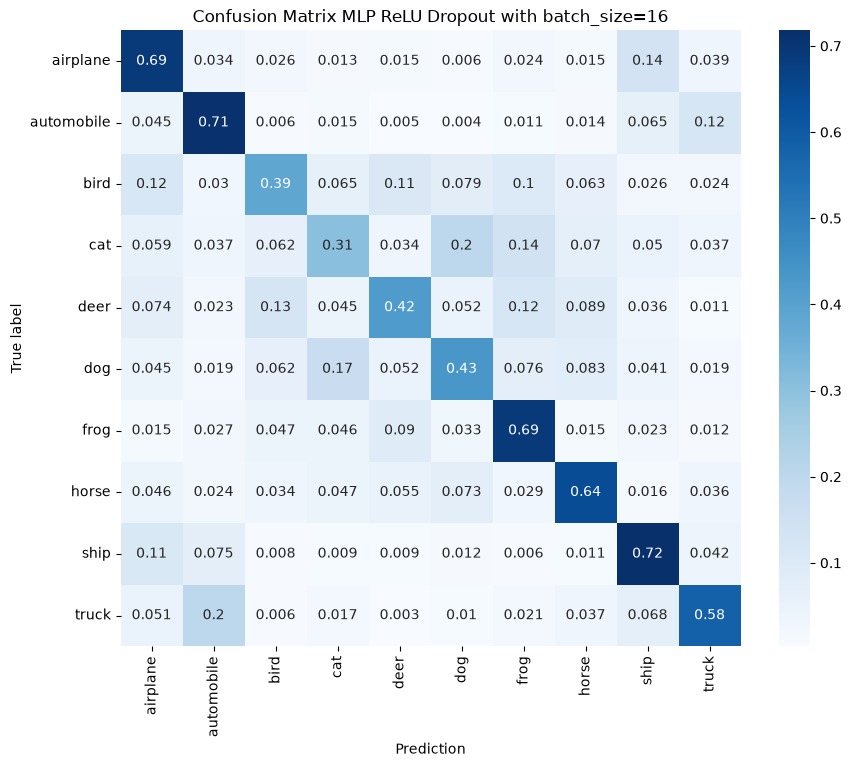

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


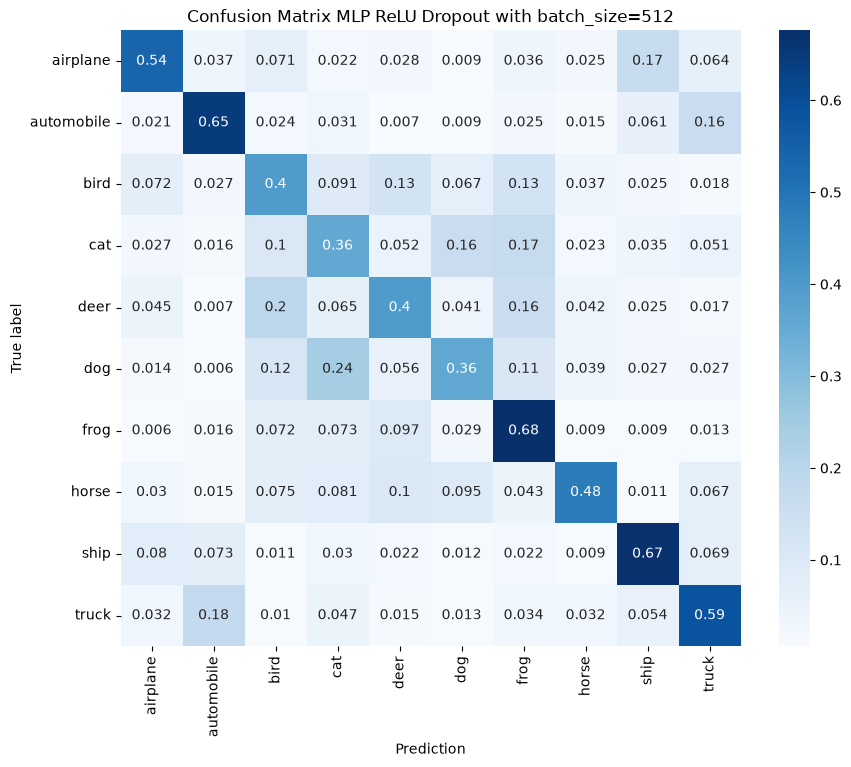

In [37]:
printConfusionMatrix(model_b16, 'MLP ReLU Dropout with batch_size=16')
printConfusionMatrix(model_b512, 'MLP ReLU Dropout with batch_size=512')

Conclusion:
- Batch_size is dependent on the other hyperparameters. Optimal hp for one batch_size may not be as good for the other, which is proven by decreasing accuracy, after changing batch_size.
- High batch_size helps model to detect more general features, but it lacks noise helpful with dealing new data.
- Diagrams above show that model with batch_size=512 confuses animal classes mostly with different animal. Confusing Animals with vehicles happens much less than using model with batch_size=16, which may be caused by underfitting

In [46]:
checkpoint_b512 = ModelCheckpoint(
    'b512_best_weights.weights.h5',
    monitor='val_loss', 
    save_weights_only=True, 
    save_best_only=True,
    mode='min'
)

model_b512.fit(
    x_train,
    y_train,
    epochs=360,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[checkpoint_b512]
)

Epoch 1/360
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5494 - loss: 1.2600 - val_accuracy: 0.5289 - val_loss: 1.3428
Epoch 2/360
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5539 - loss: 1.2469 - val_accuracy: 0.5335 - val_loss: 1.3146
Epoch 3/360
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5544 - loss: 1.2458 - val_accuracy: 0.4973 - val_loss: 1.4688
Epoch 4/360
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5463 - loss: 1.2773 - val_accuracy: 0.5251 - val_loss: 1.3511
Epoch 5/360
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5504 - loss: 1.2650 - val_accuracy: 0.5273 - val_loss: 1.3324
Epoch 6/360
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5557 - loss: 1.2453 - val_accuracy: 0.5359 - val_loss: 1.3329
Epoch 7/360
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5443 - loss: 1.2762 - val_accuracy: 0.5308 - val_loss: 1.3422
Epoch 8/360
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5485 - loss: 1.2584 - val_accuracy: 0.5389 - v

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


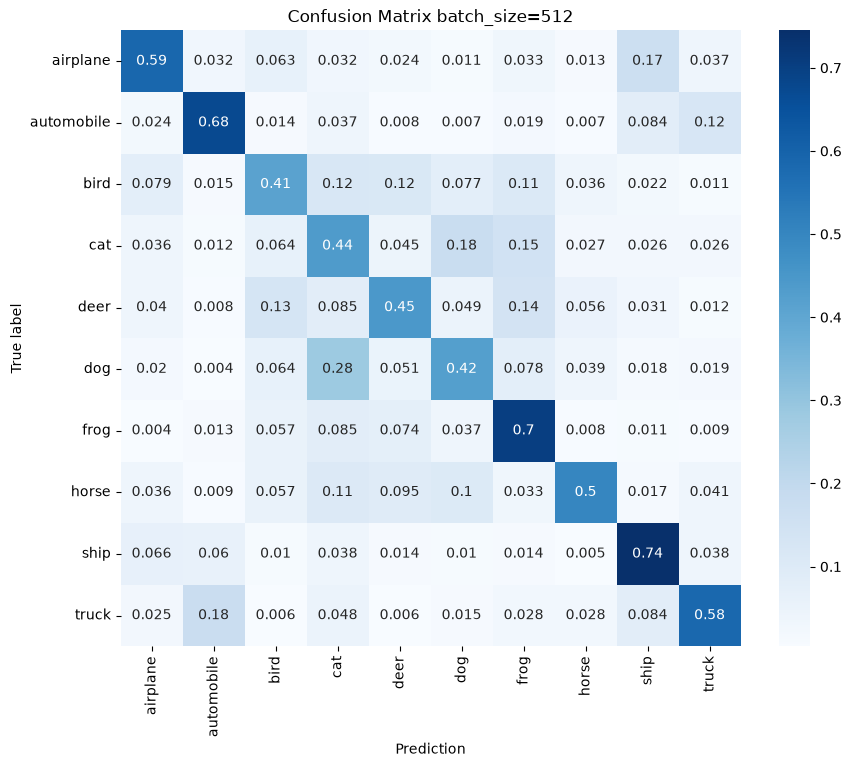

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5515 - loss: 1.2732


In [49]:
model_b512.load_weights('b512_best_weights.weights.h5')
printConfusionMatrix(model_b512, 'batch_size=512')
loss, acc = model_b512.evaluate(x_test, y_test)

### Searching the best model with batch_size as parameter

In [ ]:
class ClassificationModelWithBatchSize(kt.HyperModel):
    def build(self, hp):
        return build_model(hp)
    def fit(self, hp, model, X, y, **kwargs):
        batch_size=hp.Int('batch_size', min_value=16, max_value=128, step=16, default=32)
        return model.fit(X, y, batch_size=batch_size, **kwargs)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True)

In [ ]:
bs_tuner = kt.Hyperband(hypermodel=ClassificationModelWithBatchSize(), 
                        objective='val_loss', 
                        seed=42,  
                        max_epochs=100, 
                        hyperband_iterations=3,
                        overwrite=False,
                       )

In [ ]:
bs_tuner.search(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

Trial 662 Complete [00h 00m 19s]
val_loss: 1.6003434658050537

Best val_loss So Far: 1.3420521020889282
Total elapsed time: 04h 43m 27s

Search: Running Trial #663

Value             |Best Value So Far |Hyperparameter
3                 |6                 |n_hidden
128               |128               |n_neurons
0.00015303        |0.00095281        |learning_rate
adam              |adam              |optimizer
96                |16                |batch_size
4                 |34                |tuner/epochs
0                 |12                |tuner/initial_epoch
3                 |4                 |tuner/bracket
0                 |3                 |tuner/round



ToDo:
- Learning rate shceduler
- Data augmentation


In [ ]:
print(len(bs_tuner.oracle.trials))

In [ ]:
print("Remaining:", bs_tuner.oracle.remaining_trials)

# To FINISH

### MLP Model with Dropout and Data Augmentation

In [51]:
model_data_aug=tf.keras.Sequential()
model_data_aug.add(
    tf.keras.layers.RandomTranslation(
        height_factor=0.15,
        width_factor=0.15,
        fill_mode='reflect',
        seed=42,
    )
)

#MLP has no spacial awareness, so random rotation kills its ability to learn
#model_data_aug.add(
#   tf.keras.layers.RandomRotation(
#        factor=0.15,
#        fill_mode='reflect',
#        seed=42
#    )
#)


model_data_aug.add(
    tf.keras.layers.RandomFlip(
        "horizontal"
    )
)

#### Testing Data Augmentation

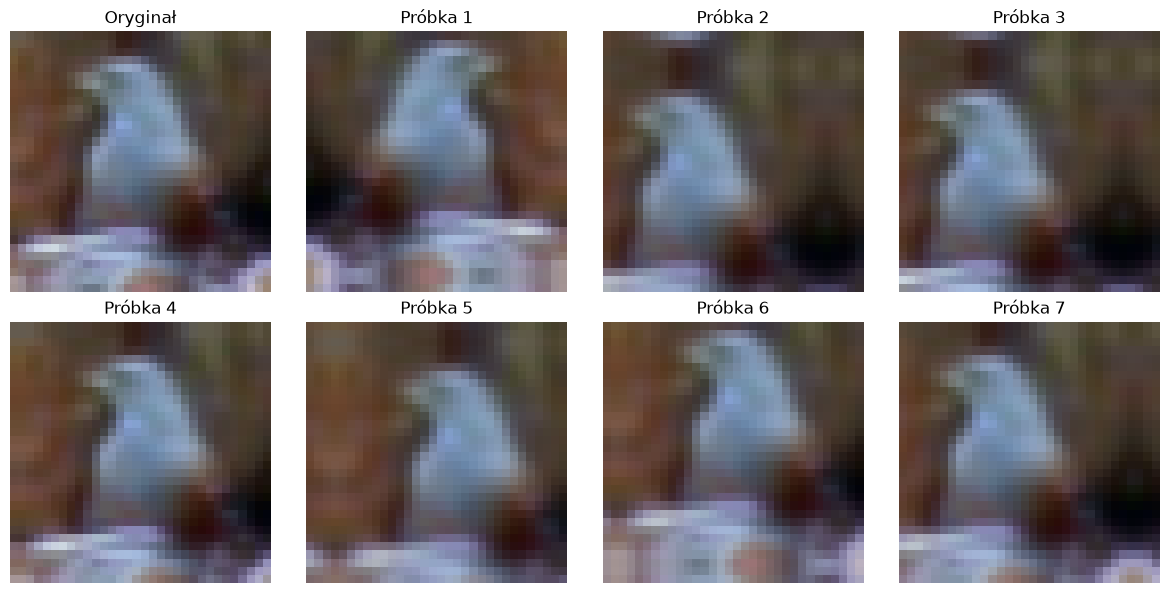

In [52]:
sample_image=x_train[4]
input_image = tf.expand_dims(sample_image, 0)
plt.figure(figsize=(12, 6))

# Obraz oryginalny
plt.subplot(2, 4, 1)
plt.imshow(sample_image)
plt.title("Oryginał")
plt.axis("off")

for i in range(7):
    augmented_image = model_data_aug(input_image, training=True)

    plt.subplot(2, 4, i + 2)
    plt.imshow(tf.squeeze(augmented_image))
    plt.title(f"Próbka {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Adding neural layers

In [53]:
print(best_hp.values)

{'n_hidden': 4, 'n_neurons': 448, 'learning_rate': 0.0004693728843708382, 'dropout': 0.4, 'optimizer': 'adam'}


In [54]:
model_data_aug.add(
    tf.keras.layers.Flatten(),
)
for _ in range(best_hp.values['n_hidden']):
    model_data_aug.add(
        tf.keras.layers.Dense(
            best_hp.values['n_neurons'],
            kernel_initializer='he_normal'
        ))
    model_data_aug.add(tf.keras.layers.BatchNormalization())
    model_data_aug.add(tf.keras.layers.Activation('relu'))
    model_data_aug.add(tf.keras.layers.Dropout(best_hp.values['dropout']/2))
model_data_aug.add(
    tf.keras.layers.Dense(
        10, activation='softmax'
    )
)

model_data_aug.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.003), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [33]:
early_stop_DA=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=10,
    restore_best_weights=True,
)

In [57]:
history = model_data_aug.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=200,
    validation_data=(x_val, y_val),
    callbacks=[early_stop_DA]
)

Epoch 1/200
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.3008 - loss: 1.9530 - val_accuracy: 0.2540 - val_loss: 1.9908
Epoch 2/200
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.3614 - loss: 1.7681 - val_accuracy: 0.3656 - val_loss: 1.7619
Epoch 3/200
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.3837 - loss: 1.7166 - val_accuracy: 0.3469 - val_loss: 1.9076
Epoch 4/200
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.3985 - loss: 1.6732 - val_accuracy: 0.3897 - val_loss: 1.7720
Epoch 5/200
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4120 - loss: 1.6400 - val_accuracy: 0.4041 - val_loss: 1.6595
Epoch 6/200
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4188 - loss: 1.6216 - val_accuracy: 0.4043 - val_loss: 1.6819
Epoch 7/200
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4248 - loss: 1.6040 - val_accuracy: 0.4425 - val_loss: 1.5379
Epoch 8/200
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 

In [58]:
loss, acc = model_data_aug.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6008 - loss: 1.1180


In [64]:
y_MC_all = mc_predict(model_data_aug, x_test, n_samples=100)

y_MC = y_MC_all.mean(axis=0)
y_predMC = y_MC.argmax(axis=1)

accuracyMC = (y_predMC == y_test.squeeze()).mean()

print(f"MC Dropout accuracy: {accuracyMC:.4f}")

MC Dropout accuracy: 0.6021


In [65]:
model_data_aug.save_weights('best_weights_DA_LRsteady.weights.h5')

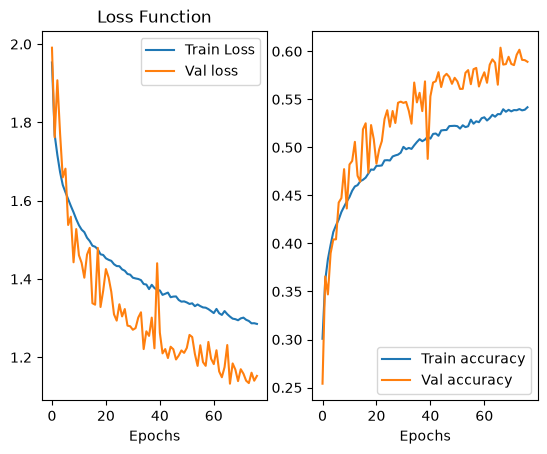

In [68]:
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss Function')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

### 1cycle lr scheduling

#### Finding max learning_rate using Exponential Learning Rate

In [34]:
class LRFinder(tf.keras.callbacks.Callback):
    def __init__(self, start_lr=1e-7, end_lr=1, maxstep=1000):
        self.step=0
        self.maxstep=maxstep
        self.start_lr=start_lr
        self.end_lr=end_lr
        self.lrs=[]
        self.losses=[]

    def on_train_begin(self, logs=None):
        self.sum_of_epoch_losses=0
        self.factor=(self.end_lr/self.start_lr)**(1/self.maxstep)
        self.model.optimizer.learning_rate = self.start_lr

    def on_epoch_begin(self, epochs, logs=None):
        self.sum_of_epoch_losses=0

    def on_batch_end(self, batch, logs=None):
        current_lr = float(
            tf.keras.backend.get_value(self.model.optimizer.learning_rate)
        )
        self.lrs.append(current_lr)

        mean_epoch_loss=logs['loss']
        new_sum_of_losses = mean_epoch_loss*(batch+1)
        loss = new_sum_of_losses-self.sum_of_epoch_losses
        self.sum_of_epoch_losses = new_sum_of_losses
        self.losses.append(loss)

        self.model.optimizer.learning_rate = current_lr*self.factor
        
        self.step+=1
        if self.step >= self.maxstep:
            self.model.stop_training = True
            return

    def plot(self):
        plt.figure(figsize=(8,5))
        plt.plot(self.lrs, self.losses)
        plt.xscale('log')
        plt.xlabel('Learning Rate')
        plt.ylabel('Loss')
        plt.axis([min(self.lrs), max(self.lrs), min(self.losses), self.losses[0]+1.0])
        plt.grid(True)
        plt.show()

        

In [35]:
class LRFinder(tf.keras.callbacks.Callback):

    def __init__(
        self, start_lr=1e-7, end_lr=10, max_steps=1000, smoothing=0.98
    ):
        super().__init__()
        self.start_lr = start_lr
        self.end_lr = end_lr
        self.max_steps = max_steps
        self.smoothing = smoothing
        self.lrs = []
        self.losses = []

    def on_train_begin(self, logs=None):
        self.step = 0
        self.best_loss = 1e9
        self.avg_loss = 0
        # Przeliczamy czynnik mnożący LR dla każdego kroku
        self.lr_mult = (self.end_lr / self.start_lr) ** (1 / self.max_steps)
        self.model.optimizer.learning_rate=self.start_lr

    def on_batch_end(self, batch, logs=None):
        self.step += 1
        loss = logs.get("loss")

        # Wygładzanie wykresu błędu (Exponential Moving Average)
        self.avg_loss = (
            self.smoothing * self.avg_loss + (1 - self.smoothing) * loss
        )
        smoothed_loss = self.avg_loss / (1 - self.smoothing**self.step)

        # Zapisujemy wartości do wykresu
        current_lr = float(
            tf.keras.backend.get_value(self.model.optimizer.learning_rate)
        )
        self.lrs.append(current_lr)
        self.losses.append(smoothed_loss)

        # Jeśli błąd wybuchnie (eksplozja gradientu), zatrzymujemy test
        if self.step > 1 and smoothed_loss > 4 * self.best_loss:
            self.model.stop_training = True
            return

        if smoothed_loss < self.best_loss:
            self.best_loss = smoothed_loss

        if self.step >= self.max_steps:
            self.model.stop_training = True
            return

        # Podnosimy learning rate na kolejny krok
        self.model.optimizer.learning_rate=current_lr * self.lr_mult

    def plot(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.lrs, self.losses)
        plt.xscale("log")
        plt.xlabel("Learning Rate (skala logarytmiczna)")
        plt.ylabel("Loss (Wygładzony)")
        plt.title("LR Finder")
        plt.grid(True)
        plt.show()

1329/1329 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1580 - loss: 6.3408


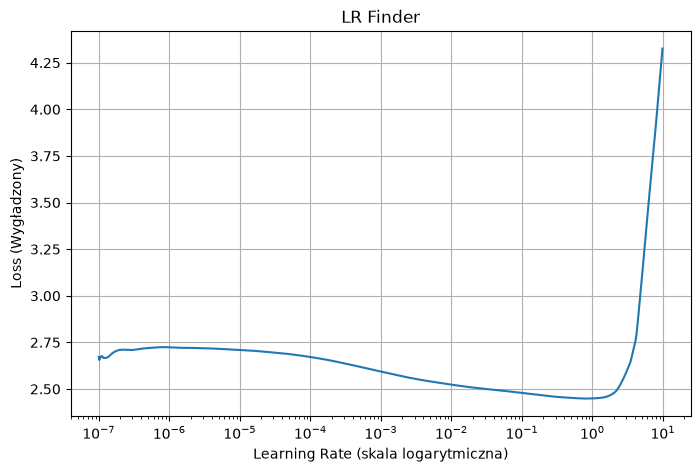

In [217]:
lr_finder = LRFinder(end_lr=10)
model_data_aug.fit(x_train, y_train, epochs=1, callbacks=[lr_finder])
lr_finder.plot()

Peak Learning Rate ~= 0.07-0.1

### OneCycleScheduler
#this code is taken from https://github.com/ageron/handson-ml3/blob/main/11_training_deep_neural_networks.ipynb

In [36]:
class OneCycleScheduler(tf.keras.callbacks.Callback):
    def __init__(self, iterations, max_lr=1e-3, start_lr=None,
                 last_iterations=None, last_lr=None):
        self.iterations = iterations
        self.max_lr = max_lr
        self.start_lr = start_lr or max_lr / 10
        self.last_iterations = last_iterations or iterations // 10 + 1
        self.half_iteration = (iterations - self.last_iterations) // 2
        self.last_lr = last_lr or self.start_lr / 1000
        self.iteration = 0

    def _interpolate(self, iter1, iter2, lr1, lr2):
        return (lr2 - lr1) * (self.iteration - iter1) / (iter2 - iter1) + lr1

    def on_batch_begin(self, batch, logs):
        if self.iteration < self.half_iteration:
            lr = self._interpolate(0, self.half_iteration, self.start_lr,
                                   self.max_lr)
        elif self.iteration < 2 * self.half_iteration:
            lr = self._interpolate(self.half_iteration, 2 * self.half_iteration,
                                   self.max_lr, self.start_lr)
        else:
            lr = self._interpolate(2 * self.half_iteration, self.iterations,
                                   self.start_lr, self.last_lr)
        self.iteration += 1
        self.model.optimizer.learning_rate = lr

In [55]:
batch_size=32
n_epochs = 300
onecycle = OneCycleScheduler(math.ceil(len(x_train) / batch_size) * n_epochs,
                             max_lr=0.003)
history = model_data_aug.fit(x_train, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_data=(x_val, y_val),
                    callbacks=[onecycle])

Epoch 1/300
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.2760 - loss: 2.0444 - val_accuracy: 0.3511 - val_loss: 1.7817
Epoch 2/300
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.3346 - loss: 1.8365 - val_accuracy: 0.3819 - val_loss: 1.7170
Epoch 3/300
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.3676 - loss: 1.7539 - val_accuracy: 0.3785 - val_loss: 1.7083
Epoch 4/300
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.3832 - loss: 1.7017 - val_accuracy: 0.4156 - val_loss: 1.6544
Epoch 5/300
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4008 - loss: 1.6656 - val_accuracy: 0.4409 - val_loss: 1.5564
Epoch 6/300
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4075 - loss: 1.6415 - val_accuracy: 0.4316 - val_loss: 1.5780
Epoch 7/300
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.4182 - loss: 1.6185 - val_accuracy: 0.4520 - val_loss: 1.5380
Epoch 8/300
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 

In [58]:
model_data_aug.save_weights('best_weights_DA_OneCycleLR.weights.h5')

In [56]:
model_data_aug.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6701 - loss: 0.9314


[0.9313969016075134, 0.6700999736785889]

In [57]:
y_MC_all = mc_predict(model_data_aug, x_test, n_samples=100)

y_MC = y_MC_all.mean(axis=0)
y_predMC = y_MC.argmax(axis=1)

accuracyMC = (y_predMC == y_test.squeeze()).mean()

print(f"MC Dropout accuracy: {accuracyMC:.4f}")

MC Dropout accuracy: 0.6707


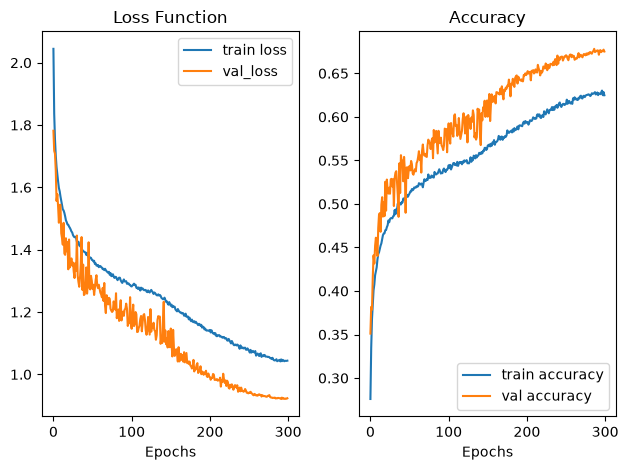

In [60]:
plt.subplot(1,2,1)
plt.title("Loss Function")
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.title("Accuracy")
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


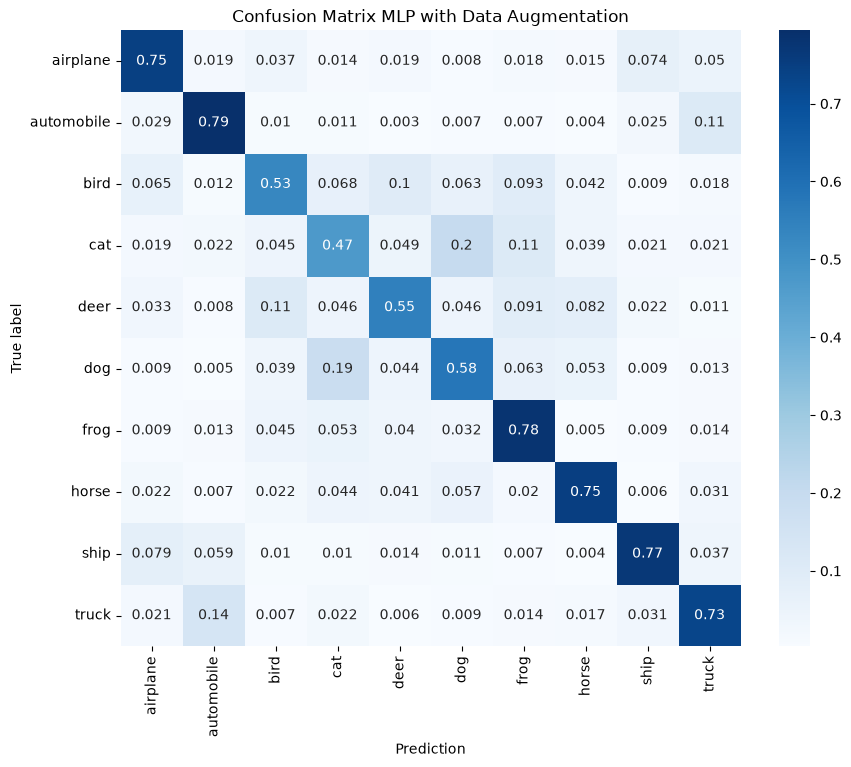

In [63]:
printConfusionMatrix(model_data_aug, 'MLP with Data Augmentation')